# SETTING UP DATA AND LIBRARIES

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## LOADING DATASET

In [5]:
import os
os.getcwd()

'/Users/abhisheksmac'

In [7]:
os.chdir('/Users/abhisheksmac/Desktop/IT Career Switch/Portfolio Project Income Classification/')

In [17]:
df = pd.read_csv("income_evaluation.csv")  # adjust name if different
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## BASIC DATA OVERVIEW

In [19]:
df.columns = df.columns.str.strip()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


## CHECK MISSING VALUES

In [20]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

# DATA PREPROCESSING SECTION

## HANDLE MISSING VALUES

In [21]:
df = df.replace("?", np.nan)

df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

In [22]:
df = df.dropna()

## ENCODING CATEGORICAL VARIABLES

In [23]:
categorical_cols = df.select_dtypes(include="object").columns

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

## FEATURE SEPARATION

In [24]:
X = df.drop("income", axis=1)
y = df["income"]

## FEATURE SCALING

In [25]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X = pd.DataFrame(X_scaled, columns=X.columns)

# EDA SECTION

## UNIVARIATE ANALYSIS

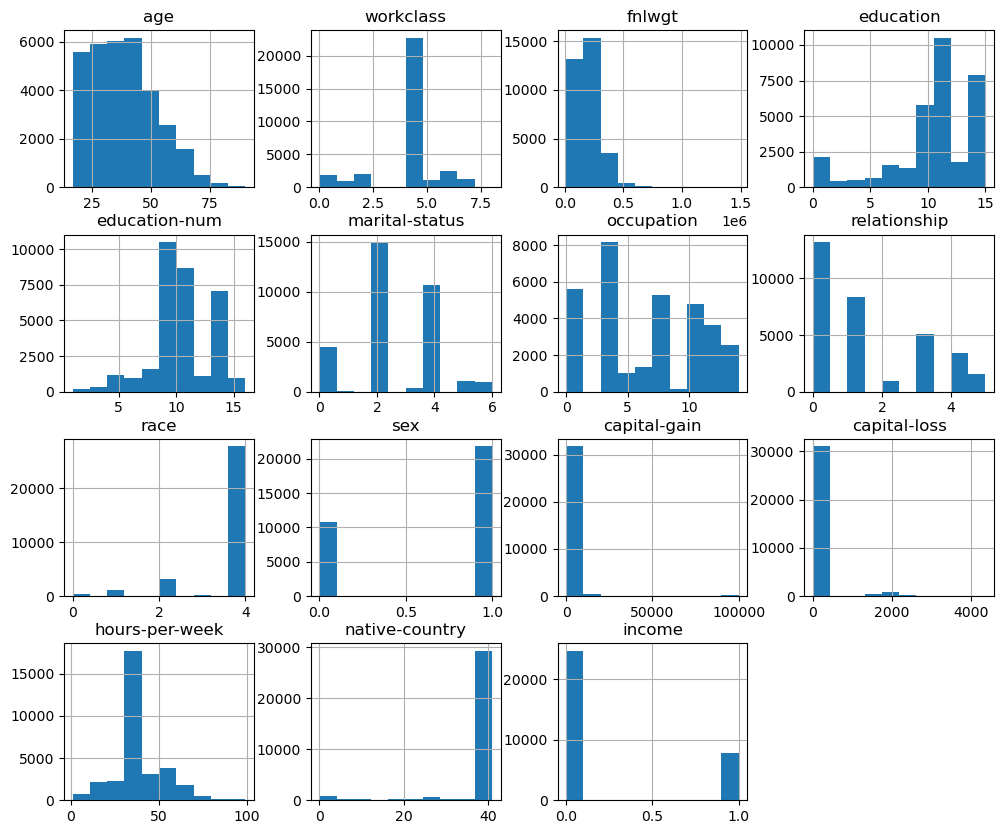

In [26]:
df.hist(figsize=(12,10))
plt.show()

## TARGET DISTRIBUTION

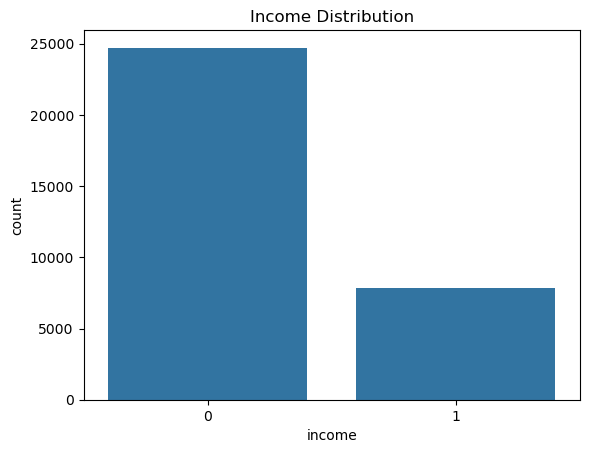

In [27]:
sns.countplot(x=y)
plt.title("Income Distribution")
plt.show()

## BIVARIATE ANALYSIS

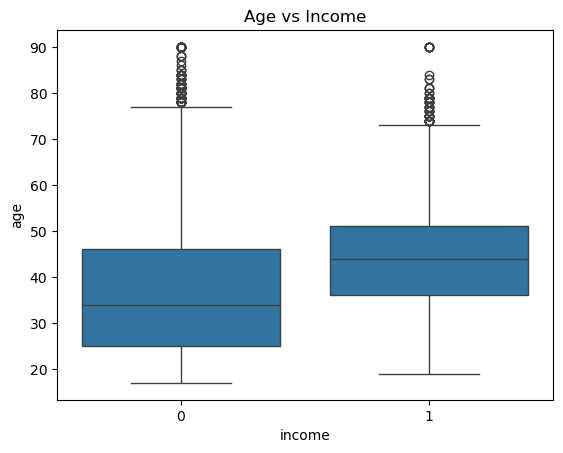

In [28]:
sns.boxplot(x=y, y=df["age"])
plt.title("Age vs Income")
plt.show()

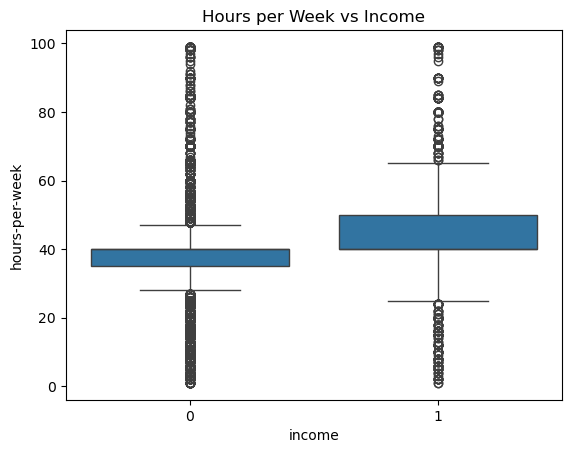

In [29]:
sns.boxplot(x=y, y=df["hours-per-week"])
plt.title("Hours per Week vs Income")
plt.show()

## CORRELATION ANALYSIS

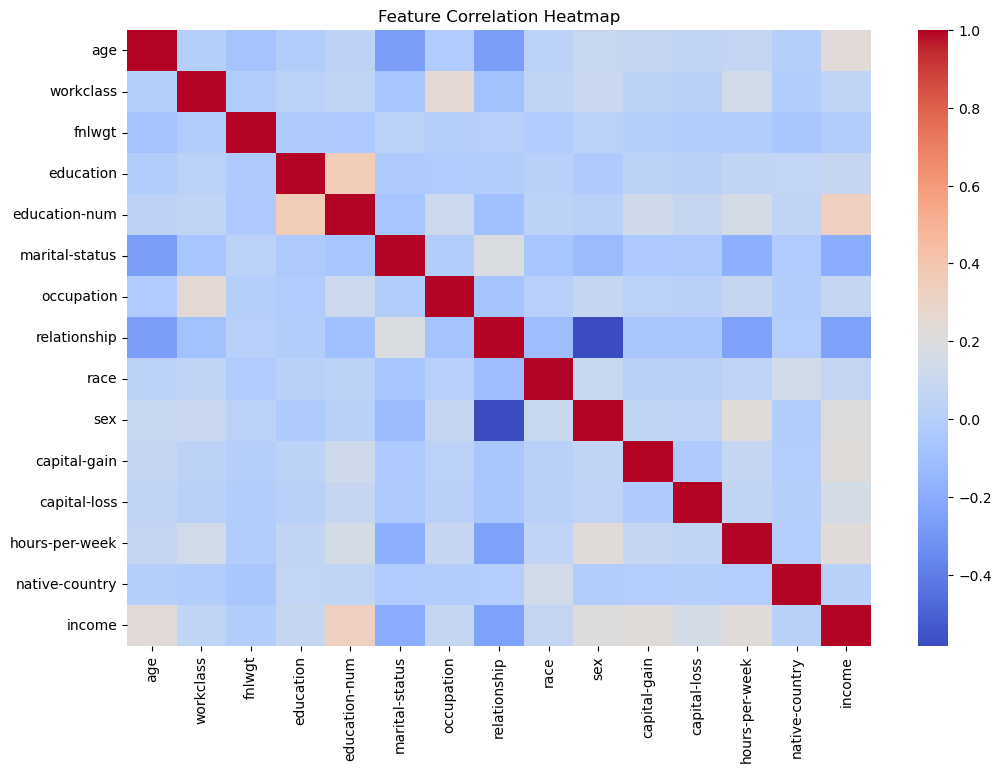

In [30]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# MACHINE LEARNING MODELS

## TRAIN TEST SPLIT

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## RANDOM FOREST (10 TREES)

In [32]:
rf_10 = RandomForestClassifier(n_estimators=10, random_state=42)
rf_10.fit(X_train, y_train)

y_pred_10 = rf_10.predict(X_test)

print("Accuracy (10 trees):", accuracy_score(y_test, y_pred_10))

Accuracy (10 trees): 0.8530631045601106


## RANDOM FOREST (100 TREES)

In [33]:
rf_100 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_100.fit(X_train, y_train)

y_pred_100 = rf_100.predict(X_test)

print("Accuracy (100 trees):", accuracy_score(y_test, y_pred_100))

Accuracy (100 trees): 0.862582527253186


# FEATURE IMPORTANCE SECTION

## FEATURE IMPORTANCE

In [34]:
importances = rf_100.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df

,Feature,Importance
2,fnlwgt,0.168514
0,age,0.153036
10,capital-gain,0.115908
7,relationship,0.100985
4,education-num,0.087907
12,hours-per-week,0.083025
6,occupation,0.069786
5,marital-status,0.064738
1,workclass,0.040908
11,capital-loss,0.035680


## PLOT FEATURE IMPORTANCE

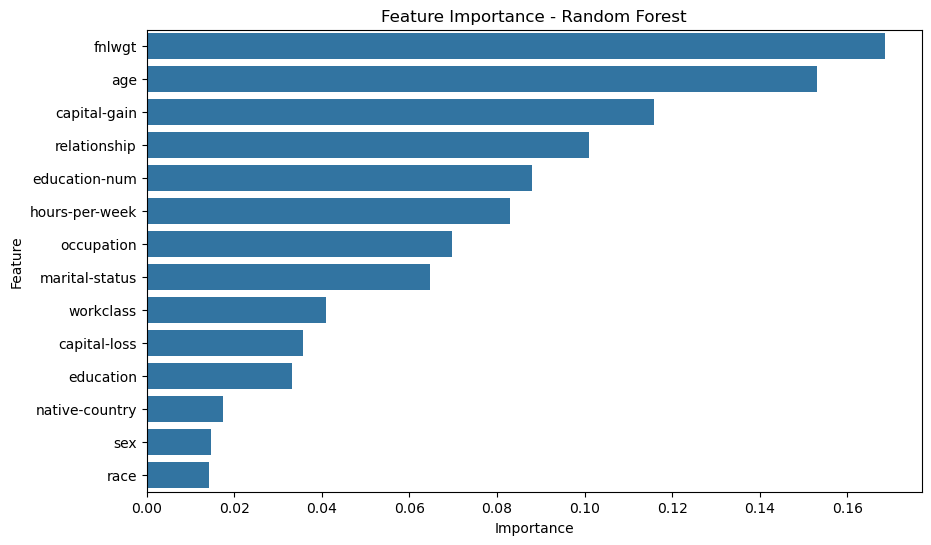

In [35]:
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feature_importance_df)
plt.title("Feature Importance - Random Forest")
plt.show()

# EVALUATION SECTION

## CONFUSION MATRIX

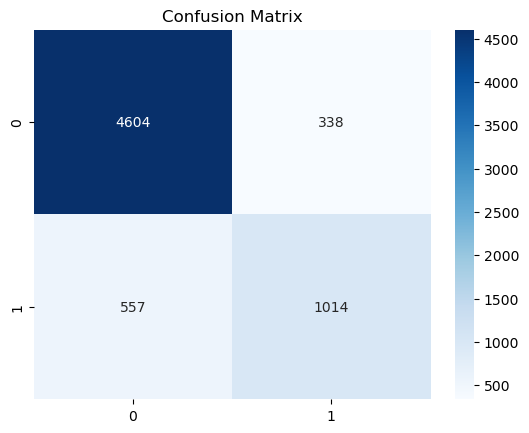

In [36]:
cm = confusion_matrix(y_test, y_pred_100)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

## CLASSIFICATION REPORT

In [37]:
print(classification_report(y_test, y_pred_100))

              precision    recall  f1-score   support

           0       0.89      0.93      0.91      4942
           1       0.75      0.65      0.69      1571

    accuracy                           0.86      6513
   macro avg       0.82      0.79      0.80      6513
weighted avg       0.86      0.86      0.86      6513



# FINAL RESULTS SUMMARY

## Results Summary

- Random Forest (10 trees): Baseline model
- Random Forest (100 trees): Improved stability and accuracy
- Most important features:
  - Capital gain
  - Education level
  - Hours per week

## Conclusion

Random Forest performs well for income classification due to its ability to handle categorical + numerical interactions.